# Autism Spectrum Disorder Detection Using Machine Learning
# Introduction

Autism Spectrum Disorder (ASD) is a developmental condition that affects communication, behavior, and social interaction. Early detection of ASD is important because it enables individuals to receive early intervention and support.

In this project, machine learning techniques are applied to analyze autism screening datasets and predict whether an individual has ASD.

# The main objectives of this project are:
- Combine autism datasets from different age groups
- Clean and preprocess the data
- Train multiple machine learning models
- Evaluate the performance of the models
- Interpret the predictions using explainable AI techniques

# Theoretical Grounding

The theoretical grounding of this project is based on the Diagnostic and Statistical Manual of Mental Disorders, Fifth Edition (DSM-5), which provides the standardized clinical criteria used by professionals to diagnose Autism Spectrum Disorder (ASD). The DSM-5 framework defines ASD using two main domains: persistent deficits in social communication and social interaction, and restricted or repetitive patterns of behavior, interests, or activities. Many of the variables in the autism screening datasets (such as behavioral screening scores and repetitive behavior indicators) are derived from screening tools that align with these DSM-5 diagnostic characteristics. In this project, the machine learning models learn patterns from these behavioral indicators to predict the ASD diagnosis label. Therefore, the DSM-5 criteria indirectly guide the selection and interpretation of features used for ASD detection.

# Why the DSM-5 Framework Was Chosen

The DSM-5 framework was selected because it is the globally recognized clinical standard used by psychologists and psychiatrists for diagnosing Autism Spectrum Disorder. Using a framework grounded in DSM-5 ensures that the machine learning predictions are aligned with established clinical diagnostic principles, making the analysis more meaningful and relevant to real-world ASD screening.

# How the Framework Was Applied in the Project

The DSM-5 framework was applied by using datasets that contain behavioral screening responses and diagnostic labels derived from ASD assessment questionnaires. These questionnaires are designed to capture behaviors associated with DSM-5 diagnostic criteria. The machine learning models were then trained to detect patterns within these features that correspond to the presence or absence of ASD.


# Importing Required Libraries

In this step, the necessary Python libraries used for data analysis, visualization, machine learning, and model interpretability are imported.

# The main libraries include:

Pandas – used for data manipulation and dataset handling
NumPy – used for numerical operations
Matplotlib and Seaborn – used for creating visualizations
Scikit-learn – used for machine learning models and evaluation metrics
XGBoost – used for gradient boosting models
SHAP – used to explain how the machine learning model makes predictions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve, PrecisionRecallDisplay
)


# Creating an Output Directory

To keep the project organized, an output folder is created where all generated figures and visualizations will be saved automatically.

These visualizations include:

- Correlation heatmaps
- Confusion matrices
- Feature importance graphs
- SHAP explanation plots

Saving outputs ensures that results can easily be reviewed and included in reports or presentations.

In [2]:
import shap
import warnings
warnings.filterwarnings("ignore")

# Step 1; Creating an Output directory
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Loading the Autism Datasets

Three autism screening datasets are used in this project:

- Adult autism dataset
- Child autism dataset
- Adolescent autism dataset

Each dataset contains questionnaire responses and demographic information that can help identify individuals who may have Autism Spectrum Disorder.

To perform a comprehensive analysis across all age groups, the datasets are combined into a single dataset. A new column called Age_Group is added to identify whether a record belongs to an adult, child, or adolescent.

In [3]:
# Step 2; Loading the datasets

adult = pd.read_csv("data/Autism_Adult_Data.csv")
child = pd.read_csv("data/Autism_Child_Data.csv")
adolescent = pd.read_csv("data/Autism_Adolescent_Data.csv")

# Add age group
adult["Age_Group"] = "Adult"
child["Age_Group"] = "Child"
adolescent["Age_Group"] = "Adolescent"

# Combine datasets
df = pd.concat([adult, child, adolescent], ignore_index=True)
print("Combined Dataset Shape:", df.shape)
print("\nDATASET OVERVIEW")
print(df.head())

Combined Dataset Shape: (1100, 23)

DATASET OVERVIEW
   id  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0   1         1         1         1         1         0         0         1   
1   2         1         1         0         1         0         0         0   
2   3         1         1         0         1         1         0         1   
3   4         1         1         0         1         0         0         1   
4   5         1         0         0         0         0         0         0   

   A8_Score  A9_Score  ...       ethnicity jundice austim  contry_of_res  \
0         1         0  ...  White-European      no     no  United States   
1         1         0  ...          Latino      no    yes         Brazil   
2         1         1  ...          Latino     yes    yes          Spain   
3         1         0  ...  White-European      no    yes  United States   
4         1         0  ...               ?      no     no          Egypt   

  used_app_befo

# Dataset Evaluation and Validation

To ensure the reliability of the analysis, the dataset was evaluated and validated before model training. First, data cleaning was performed by handling missing values, removing invalid entries (such as “?”), and dropping unnecessary columns like IDs. This ensured that the dataset contained consistent and usable information.
Next, feature inspection and correlation analysis were conducted to identify potential data leakage or features that were perfectly correlated with the target variable (Class/ASD). Any such features were removed to prevent biased model predictions. Additionally, visualizations such as correlation heatmaps and class distribution plots were used to understand relationships between variables and verify that the dataset was suitable for machine learning modeling.
Finally, the dataset was validated through train–test splitting, where 80% of the data was used for training and 20% for testing while maintaining the class distribution. This approach ensured that model performance was evaluated on unseen data, helping confirm that the dataset supports reliable prediction of Autism Spectrum Disorder.

# Data Cleaning

Before building machine learning models, the dataset must be cleaned to ensure data quality.

The following preprocessing steps are applied:

- Missing values represented by "?" are replaced with NaN values.
- Rows containing missing values are removed.
- Unnecessary columns such as id are dropped.
- Column names are standardized by removing extra spaces.

These steps ensure that the dataset is consistent and suitable for machine learning.

In [4]:
# Step 3; Data cleaning

df = df.replace("?", np.nan)
df = df.dropna()

if "id" in df.columns:
    df = df.drop(columns=["id"])

df.columns = df.columns.str.strip()

# Encoding Categorical Features

Machine learning algorithms require numerical input data. However, several features in the dataset are categorical, such as gender, ethnicity, and relation.

To convert these categorical values into numeric form, Label Encoding is used. This technique assigns each category a unique numeric value.

# For example:

Female → 0

Male → 1

This allows machine learning algorithms to process categorical variables effectively.

In [5]:
# Step 4; encoding categorical features

label_encoders = {}
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    df[col] = df[col].astype(str)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Checking for Data Leakage

Data leakage occurs when a feature contains information that directly reveals the target variable. This can lead to unrealistically high model performance because the model essentially learns the answer.

To prevent this issue, a correlation check is performed between each feature and the target variable Class/ASD.

If any feature is perfectly correlated with the target variable, it is removed to ensure that the model learns genuine patterns from the data.

In [6]:
# Check for data leakage/ Perfect Correlation

TARGET_COL = "Class/ASD"
corr_with_target = df.corr()[TARGET_COL].sort_values(ascending=False)
leaky_features = corr_with_target[(corr_with_target == 1.0) | (corr_with_target == -1.0)]
leaky_features = leaky_features.drop(TARGET_COL, errors='ignore')

if not leaky_features.empty:
    print("\nWARNING: Perfectly correlated features with target detected!")
    print(leaky_features)
    df = df.drop(columns=leaky_features.index.tolist())
else:
    print("\nNo features perfectly correlated with target. Proceeding...")


No features perfectly correlated with target. Proceeding...


# Feature Correlation Heatmap

A correlation heatmap is used to visualize relationships between features in the dataset.

The heatmap helps identify how strongly variables are related to one another and to the target variable.

Correlation values range between -1 and 1:

Values close to 1 indicate a strong positive relationship

Values close to -1 indicate a strong negative relationship

Values close to 0 indicate weak or no relationship

This visualization helps identify which features may be important for predicting ASD.

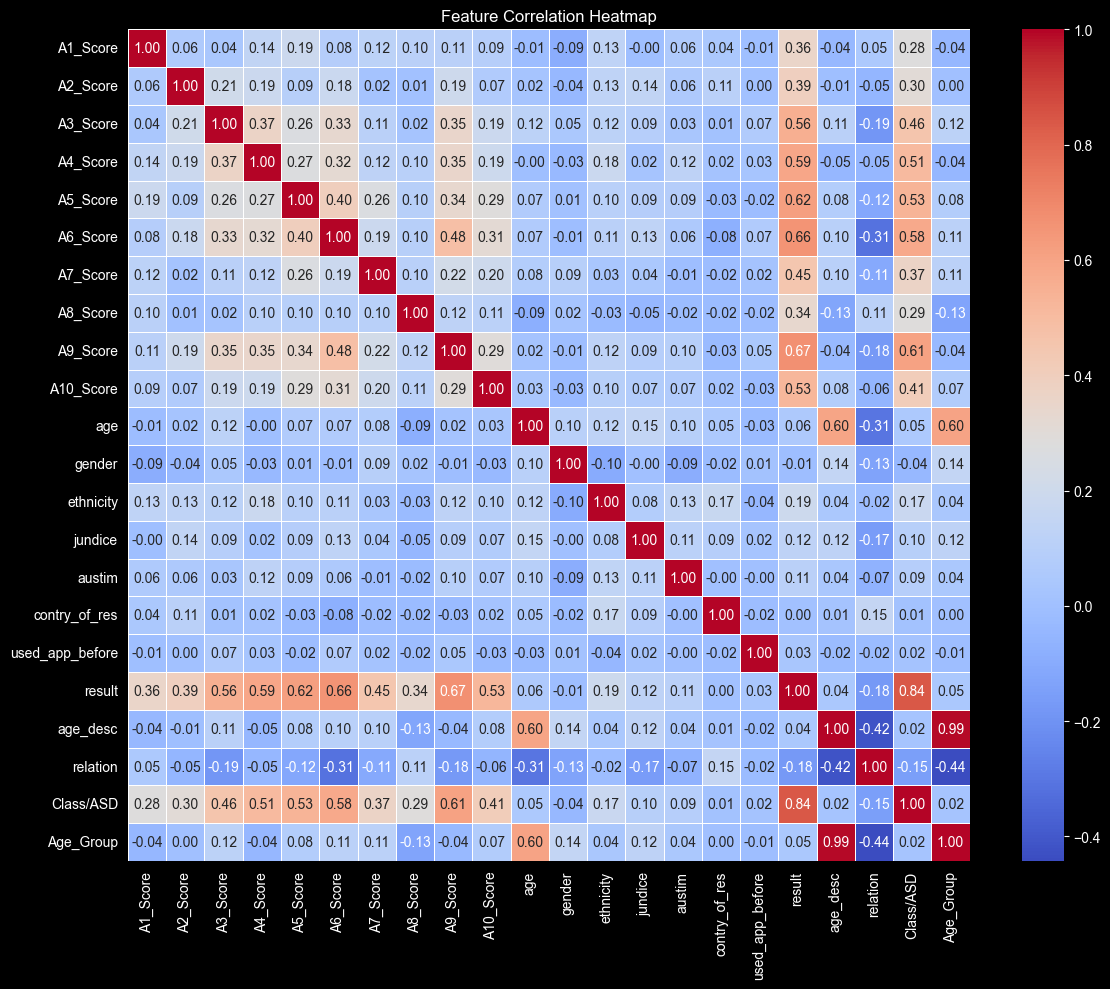

In [7]:
# Step 4b; Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.tiff", dpi=300)
plt.show()

# Target Variable Distribution

The target variable Class/ASD indicates whether an individual has autism.

A distribution plot is created to show how many individuals fall into each category:

0 – Individuals without ASD

1 – Individuals with ASD

Understanding the class distribution is important because highly imbalanced datasets can influence machine learning model performance.


Features used for training (20 total):
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'age_desc', 'relation', 'Age_Group']


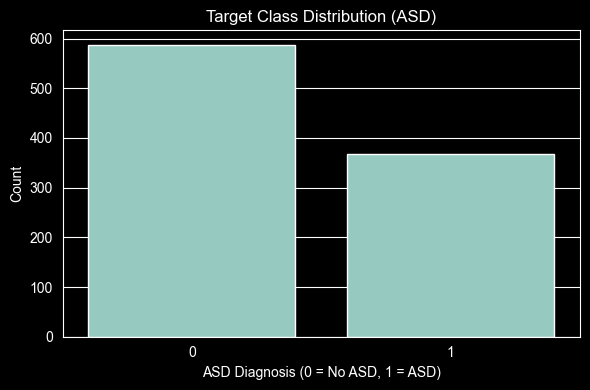


Target class distribution:
 Class/ASD
0    587
1    368
Name: count, dtype: int64


In [8]:
# Step 5; Features & Target
# ---------------------------------------------------------------
# DROP 'result' here — it is a composite score computed directly
# from A1-A10 and dominates SHAP values, masking the individual
# behavioral features we want to explain.
# ---------------------------------------------------------------
TARGET_COL = "Class/ASD"
X = df.drop(columns=[TARGET_COL])
X = X.drop(columns=['result'], errors='ignore')  # <-- FIX: drop before training
y = df[TARGET_COL]

print(f"\nFeatures used for training ({X.shape[1]} total):")
print(X.columns.tolist())

# Step 6; Target Distribution Plot

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Target Class Distribution (ASD)")
plt.xlabel("ASD Diagnosis (0 = No ASD, 1 = ASD)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/target_class_distribution.tiff", dpi=300)
plt.show()

print("\nTarget class distribution:\n", y.value_counts())

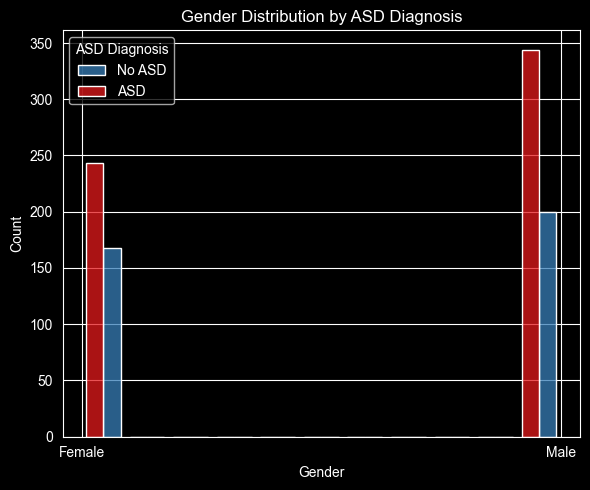

In [9]:
# Feature Histogram: Gender vs Class/ASD Target Variable

plt.figure(figsize=(6,5))
sns.histplot(
    data=df,
    x='gender',
    hue='Class/ASD',
    multiple='dodge',
    shrink=0.8,
    palette='Set1'
)
plt.xticks([0,1], ['Female', 'Male'])
plt.title("Gender Distribution by ASD Diagnosis")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title='ASD Diagnosis', labels=['No ASD', 'ASD'])
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hist_gender_by_ASD.tiff", dpi=300)
plt.show()


# Splitting the Dataset into Training and Testing Sets

To evaluate model performance accurately, the dataset is divided into two parts:

- Training set (80%) – used to train the machine learning models

- Testing set (20%) – used to evaluate model performance

Stratified sampling is used to ensure that the proportion of ASD and non-ASD cases remains consistent in both the training and testing datasets.

In [10]:
# Step 7; Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Train class ratio (ASD=1): {y_train.mean():.2%}, Test class ratio: {y_test.mean():.2%}")


Train samples: 764, Test samples: 191
Train class ratio (ASD=1): 38.48%, Test class ratio: 38.74%


In [11]:
# Step 8; Feature Scaling

numeric_cols = X.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Machine Learning Models

# Four models are trained and compared in this project.

- Baseline Model (Dummy Classifier)
A simple model that always predicts the most frequent class. It serves as a benchmark for comparison.

- Logistic Regression
A statistical model commonly used for binary classification problems.

- Random Forest
An ensemble learning method that combines multiple decision trees to improve predictive performance.

- XGBoost
A powerful gradient boosting algorithm known for its high performance in many machine learning tasks.

Comparing multiple models helps identify the most effective algorithm for ASD detection.

In [12]:
# Step 9; Model Training

# Baseline Model
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Logistic Regression Model
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])
log_pipeline.fit(X_train, y_train)

# Random Forest Model
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

# XGBoost Model
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42))
])
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


# Model Evaluation Metrics

Several metrics are used to evaluate the performance of the models:

- Accuracy – measures the proportion of correct predictions
- Precision – measures how many predicted ASD cases are correct
- Recall – measures the ability of the model to detect ASD cases
- F1 Score – balances precision and recall
- PR-AUC – measures performance using the precision-recall curve

These metrics provide a comprehensive understanding of how well the models perform.

In [13]:
# Step 10; Predictions & Probabilities
baseline_preds = baseline.predict(X_test)
rf_preds       = rf_pipeline.predict(X_test)
xgb_preds      = xgb_pipeline.predict(X_test)
log_preds      = log_pipeline.predict(X_test)

baseline_probs = baseline.predict_proba(X_test)[:,1]
rf_probs       = rf_pipeline.predict_proba(X_test)[:,1]
xgb_probs      = xgb_pipeline.predict_proba(X_test)[:,1]
log_probs      = log_pipeline.predict_proba(X_test)[:,1]

# Precision-Recall Curve

The Precision-Recall curve evaluates the performance of classification models when focusing on the positive class (ASD).

It shows the trade-off between precision and recall across different threshold values.

The PR-AUC score summarizes this curve and indicates how well the model distinguishes between ASD and non-ASD cases.

In [14]:
# Step 11; Model Performance Comparison

def pr_auc_score(y_true, probs):
    return average_precision_score(y_true, probs)

results = pd.DataFrame({
    "Model": ["Baseline","Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    "Precision":[
        precision_score(y_test, baseline_preds, zero_division=0),
        precision_score(y_test, log_preds),
        precision_score(y_test, rf_preds),
        precision_score(y_test, xgb_preds)
    ],
    "Recall":[
        recall_score(y_test, baseline_preds, zero_division=0),
        recall_score(y_test, log_preds),
        recall_score(y_test, rf_preds),
        recall_score(y_test, xgb_preds)
    ],
    "F1 Score":[
        f1_score(y_test, baseline_preds, zero_division=0),
        f1_score(y_test, log_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds)
    ],
    "PR-AUC":[
        pr_auc_score(y_test, baseline_probs),
        pr_auc_score(y_test, log_probs),
        pr_auc_score(y_test, rf_probs),
        pr_auc_score(y_test, xgb_probs)
    ]
})
print("\nMODEL PERFORMANCE COMPARISON")
print(results)


MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score    PR-AUC
0             Baseline  0.612565   0.000000  0.000000  0.000000  0.387435
1  Logistic Regression  1.000000   1.000000  1.000000  1.000000  1.000000
2        Random Forest  0.952880   0.933333  0.945946  0.939597  0.991151
3              XGBoost  0.947644   0.910256  0.959459  0.934211  0.992250


This code evaluates the performance of all the trained models by generating classification reports. A dictionary called models_preds stores each model’s name and its corresponding predictions. A for loop then iterates through the dictionary, printing the model name and using classification_report() to compare the actual labels (y_test) with the predicted labels. The report displays key metrics such as precision, recall, F1-score, and support for each model, helping to compare how well they classify ASD and non-ASD cases.

In [15]:
# Step 12; Classification Reports For All Models

models_preds = {
    "Baseline": baseline_preds,
    "Logistic Regression": log_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds
}

for name, preds in models_preds.items():
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, preds, zero_division=0))


--- Baseline Classification Report ---
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       117
           1       0.00      0.00      0.00        74

    accuracy                           0.61       191
   macro avg       0.31      0.50      0.38       191
weighted avg       0.38      0.61      0.47       191


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       117
           1       1.00      1.00      1.00        74

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       117
           1       0.93      0.95      0.94        74

    accuracy                           0.95   

This code generates side-by-side confusion matrices for the Random Forest and XGBoost models. It first creates a figure with two subplots. For each model, it computes the confusion matrix comparing the model predictions (rf_preds or xgb_preds) to the true labels (y_test) and visualizes it using Seaborn’s heatmap, labeling axes as “Predicted” and “Actual” with class names. Finally, it formats, saves, and displays the figure for analysis of model performance.

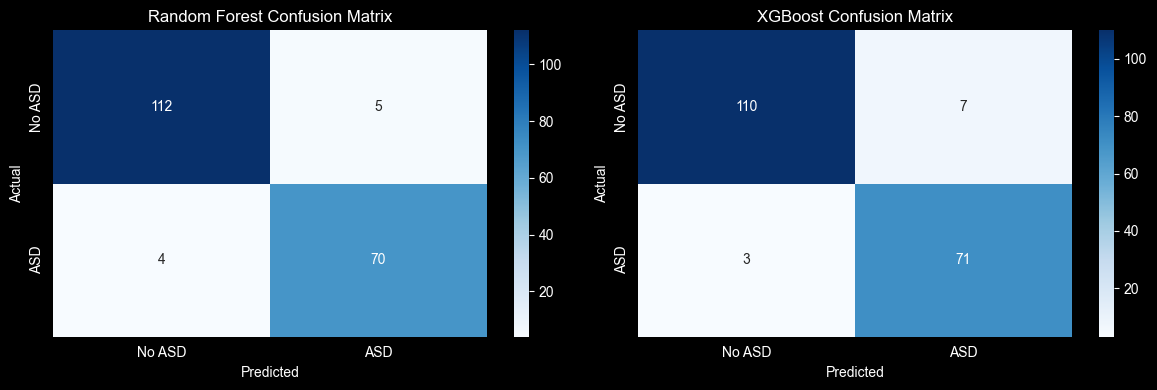

In [16]:
# Step 13; Confusion Matrices (RF & XGB)

fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax, preds, title in zip(
    axes,
    [rf_preds, xgb_preds],
    ["Random Forest", "XGBoost"]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No ASD','ASD'], yticklabels=['No ASD','ASD'])
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.tiff", dpi=300)
plt.show()

This code plots precision-recall (PR) curves for all four models—Baseline, Logistic Regression, Random Forest, and XGBoost—on the same figure for comparison. It first creates a figure, then iterates over each model, computing the predicted probabilities for the positive class. Using precision_recall_curve, it calculates precision and recall values, then plots them with the PR-AUC score in the legend. The plot is labeled, styled with a grid, saved to the outputs folder, and displayed, allowing visual assessment of each model’s ability to balance precision and recall for ASD detection.

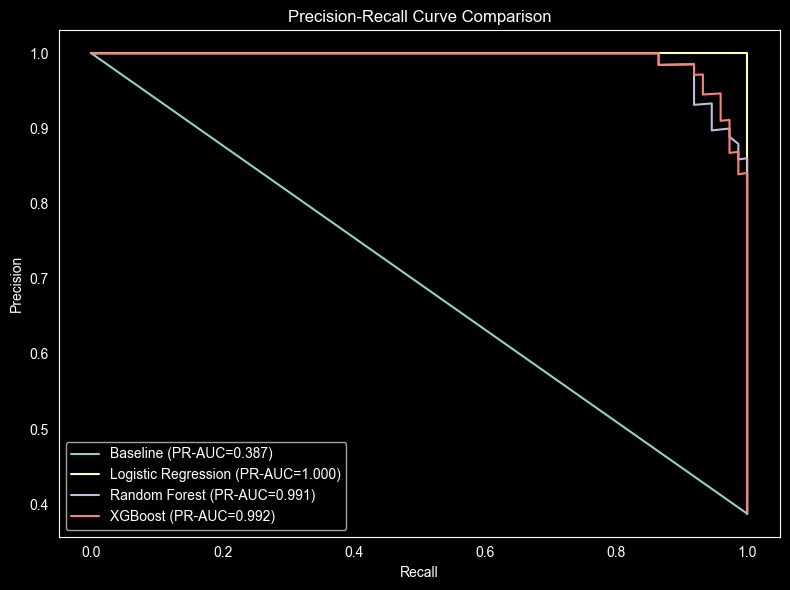

In [17]:
# Step 14; Precision-Recall Curves (Combined)

plt.figure(figsize=(8,6))
models = {
    "Baseline": baseline,
    "Logistic Regression": log_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curve_comparison.tiff", dpi=300)
plt.show()

This code visualizes the feature importance of the Random Forest model, showing which features most influence ASD predictions. First, it extracts the trained Random Forest model from the pipeline and accesses its feature_importances_ attribute. These values are paired with feature names in a DataFrame, sorted descending by importance. A horizontal bar plot is then created using Seaborn, labeled, saved to the outputs folder, and displayed, allowing clear identification of the most predictive features in the dataset.

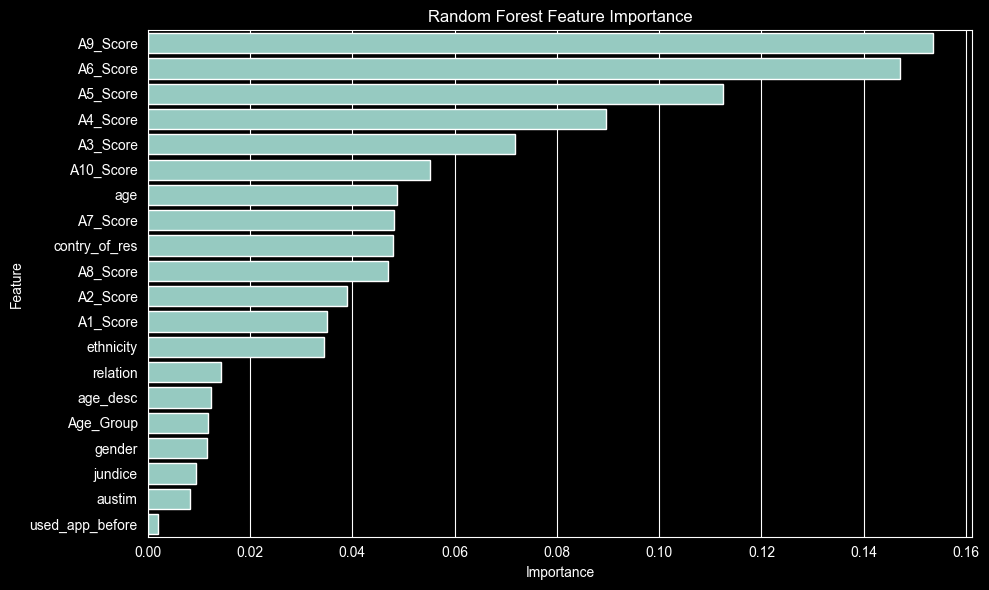

In [18]:
# Step 15; Random Forest Feature Importance

rf_model = rf_pipeline.named_steps["model"]
feature_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rf_feature_importance.tiff", dpi=300)
plt.show()

This code implements SHAP (SHapley Additive exPlanations) to interpret the XGBoost model’s predictions. First, it extracts the trained XGBoost model from the pipeline. Then, a TreeExplainer object is created, which calculates SHAP values for tree-based models. Finally, explainer(X_test) computes the SHAP values for each feature in the test set, quantifying how much each feature contributes to the model’s prediction for every individual. This enables both global and local explainability.

In [19]:
# Step 16: SHAP Explainability (XGBoost)
# 'result' is already excluded from training so X_test is clean —
# no need to drop anything here.

xgb_model = xgb_pipeline.named_steps["model"]
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

This code generates a global SHAP summary plot to visualize how each feature influences the XGBoost model’s predictions across the entire test set. shap.summary_plot combines feature importance with the direction of influence (positive or negative) for all features. show=False prevents automatic display, allowing the figure to be adjusted. plt.tight_layout() ensures proper spacing, and the plot is saved as shap_summary.png before being displayed.

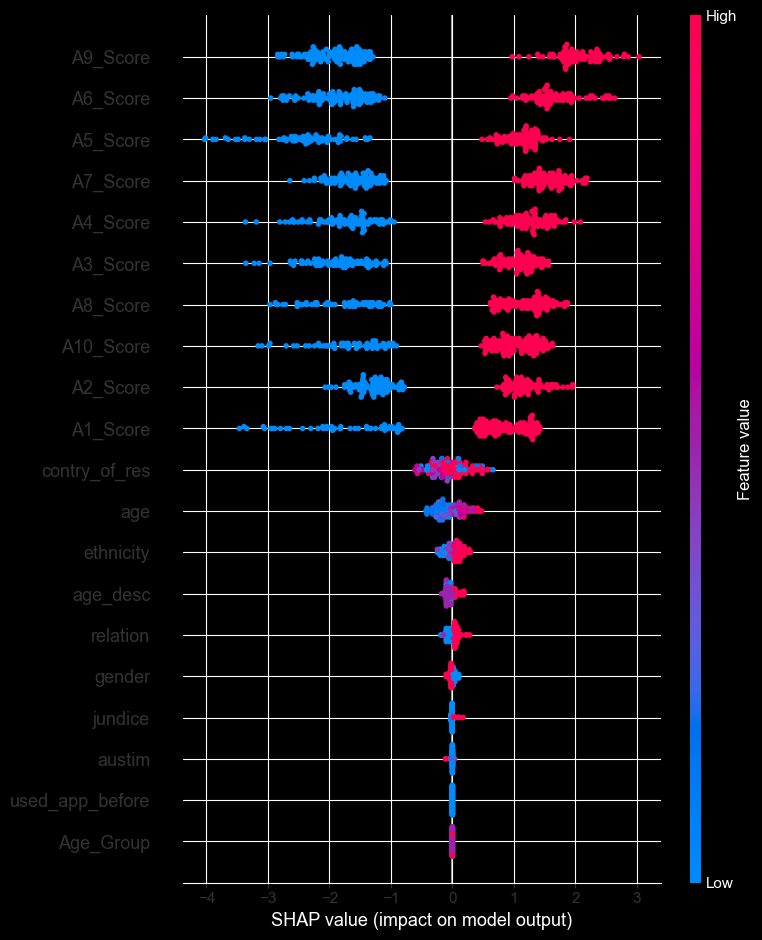

In [20]:
# 16a. Global summary
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary.tiff", dpi=300)
plt.show()

This code creates a local SHAP explanation for a single individual in the test set who does not have ASD. It first finds the index of the first person with Class/ASD = 0 using argmax(). A figure is initialized, and shap.plots.waterfall visualizes how each feature contributes positively or negatively to this person’s prediction. The plot is titled, adjusted with tight_layout(), saved as shap_local_no_asd.png, and then displayed.

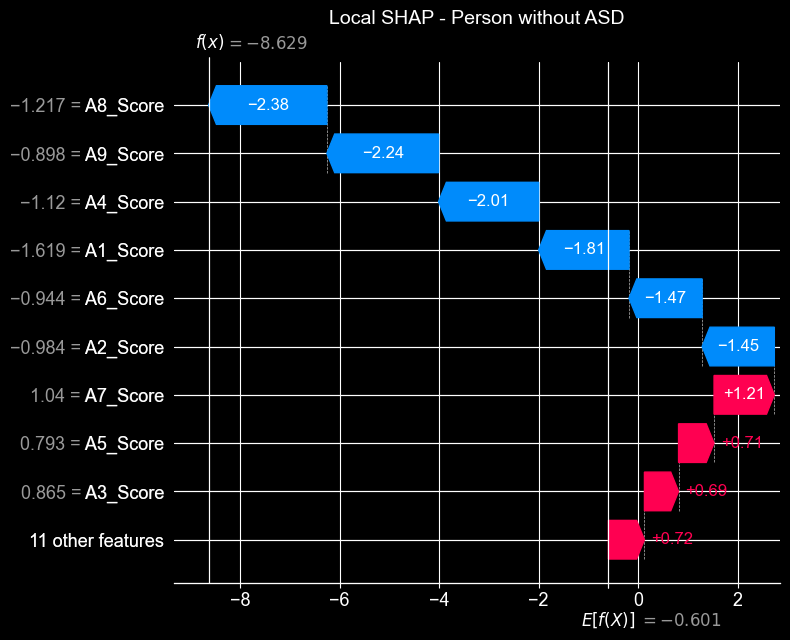

In [21]:
# 16b. Local explanation - Person WITHOUT ASD
idx_no_asd = (y_test == 0).values.argmax()
plt.figure(figsize=(12,6))
shap.plots.waterfall(shap_values[idx_no_asd], show=False)
plt.title("Local SHAP - Person without ASD", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_local_no_asd.tiff", dpi=300)
plt.show()

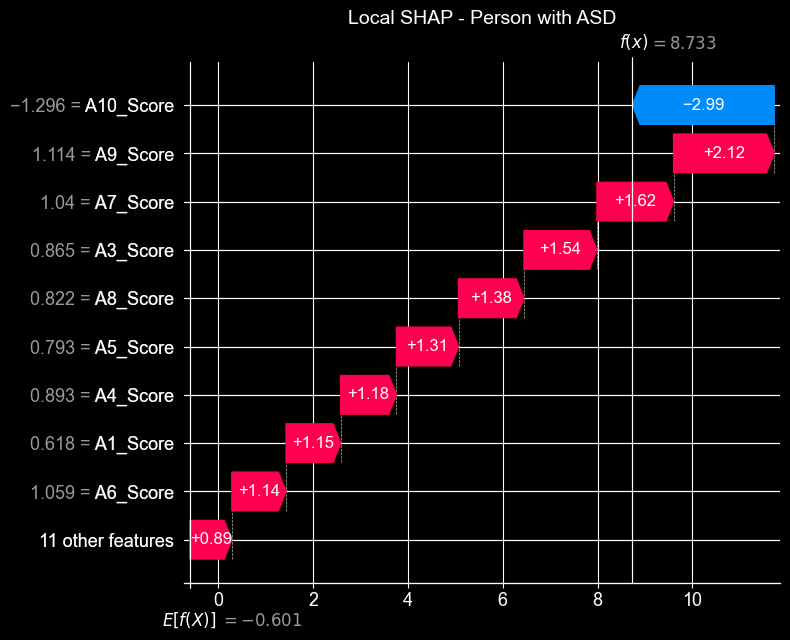

In [22]:
# 16c. Local explanation - Person WITH ASD
idx_asd = (y_test == 1).values.argmax()
plt.figure(figsize=(12,6))
shap.plots.waterfall(shap_values[idx_asd], show=False)
plt.title("Local SHAP - Person with ASD", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_local_asd.tiff", dpi=300)
plt.show()

This code generates a local SHAP explanation for a single individual in the test set who has ASD. It identifies the index of the first person with Class/ASD = 1 using argmax(). A new figure is created, and shap.plots.waterfall shows how each feature either increases or decreases the model’s prediction for this individual. The plot is titled, formatted with tight_layout(), saved as shap_local_asd.png, and displayed.

In [23]:
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")


All outputs saved to: outputs/


# Conclusion

This project demonstrated how machine learning techniques can be used to detect Autism Spectrum Disorder using screening datasets.

The workflow included data cleaning, feature encoding, training multiple models, evaluating performance, and interpreting predictions using explainable AI techniques.

The results show that machine learning models such as Random Forest and XGBoost can effectively learn patterns associated with ASD detection.

Explainable AI methods such as SHAP further help understand how the models make predictions, which is important for real-world applications in healthcare and early ASD screening.